# Results of UC-maps for Odd Patients

In [3]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uc_visualization import plot_reduced_heatmaps

# go two levels up to reach 'ERP_analysis_code'
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# add to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)

# import modules
from results.results_functions import extract_ews_v3, extract_tws_v3
from results.db import patients_db

In [5]:
import pandas as pd
import seaborn as sns
from uc_results import df_UC_results_combined, df_UC_results_patient
from itertools import chain


def store_patient_results_as_csv(patient_list):
    """Store for each patient separately the UC grid search results
    
    Function reads pickle files from online simulations, create pandas dataframe and stores it as csv
    Two csv are stored per patients: 1) all_UC_results (for every session) and 2) mean_UC_results (average over sessions)"""

    for p in patient_list:

        # Store results of all sessions per UC-pair
        df = df_UC_results_patient(p)
        df.to_csv(f"all_UC_results_p{p}.csv")
        
        # Store average results across sessions per UC-pair
        df_mean = df_UC_results_patient(p, only_mean=True)
        df_mean.to_csv(f"mean_UC_results_p{p}.csv")

# Store UC grid search results of every odd patient in csv files 
patient_list = [1, 3, 5, 7, 9]
store_patient_results_as_csv(patient_list=patient_list)

# Store UC grid search results of all even patients
df_mean = df_UC_results_combined("odd")
df_mean.to_csv(f"mean_UC_results_odd.csv")

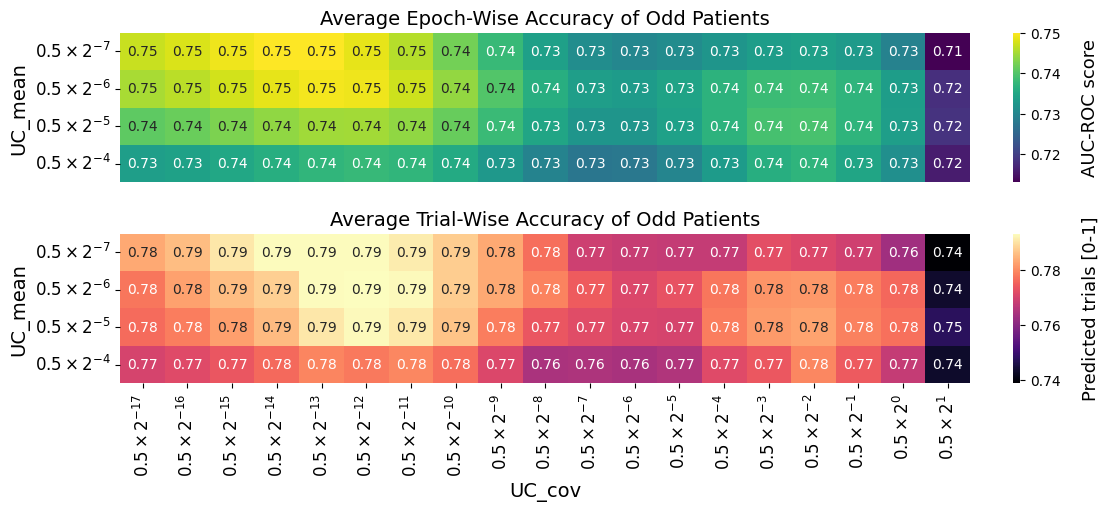

In [8]:
# Plot heatmap
from uc_visualization import plot_reduced_heatmaps
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Combined heatmap (patients grouped together)

# To plot the heatmap of a group of patients (even/odd), fill in the following two lines
patient_title = "Odd Patients"
even_or_odd = "odd" 

directory = "dataframes/"
df = pd.read_csv(f"{directory}mean_UC_results_{even_or_odd}.csv")
pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")
pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")
#plot_reduced_heatmaps(pivot_ews=pivot_ews, pivot_tws=pivot_tws, patient_title=patient_title) 


# Reduced range
UC_mean_exponents = np.arange(-7, -2)  
UC_mean_exponents = UC_mean_exponents[:4]
UC_mean_range = 0.5 * (2.0 ** UC_mean_exponents)
UC_cov_exponents = np.arange(-17, 2)  
UC_cov_range = 0.5 * (2.0 ** UC_cov_exponents)


patient_title = "Odd Patients" # Choose between "Even Patients" or "Odd Patients"
even_or_odd = "odd" # Choose between "even" or "odd" 

df = pd.read_csv(f"{directory}mean_UC_results_{even_or_odd}.csv")
pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")
pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")

fig,(ax1,ax2) = plt.subplots(nrows=2, figsize=(11,5), sharex=True, constrained_layout=True)

# Plot first heatmap (Epoch-Wise Score)
sns.heatmap(pivot_ews, annot=True, fmt=".2f", cmap="viridis", ax=ax1, cbar_kws={"label": "AUC-ROC score"})
ax1.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax1.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=12)
cbar = ax1.collections[0].colorbar
cbar.set_label("AUC-ROC score", fontsize=13, rotation=90, labelpad=15)
ax1.set_xlabel(" ")
ax1.set_xticklabels([])
ax1.tick_params(axis='x', bottom=False, top=False)
ax1.set_ylabel("UC_mean", fontsize=14)
ax1.set_title(f"Average Epoch-Wise Accuracy of {patient_title}", fontsize=14)

# Plot second heatmap (Trial-Wise Score)
sns.heatmap(pivot_tws, annot=True, fmt=".2f", cmap="magma", ax=ax2, cbar_kws={"label": "Predicted trials [0-1]"})
ax2.set_yticks(np.arange(len(UC_mean_range)) + 0.5)
ax2.set_yticklabels([fr"$0.5 \times 2^{{{y}}}$" for y in UC_mean_exponents], rotation=0, fontsize=12)
ax2.set_xticks(np.arange(len(UC_cov_range)) + 0.5)
ax2.set_xticklabels([fr"$0.5 \times 2^{{{x}}}$" for x in UC_cov_exponents], rotation=90, fontsize=12)
cbar = ax2.collections[0].colorbar
cbar.set_label("Predicted trials [0-1]", fontsize=13, rotation=90, labelpad=15)
ax2.set_xlabel("UC_cov", fontsize=14)
ax2.set_ylabel("UC_mean", fontsize=14)
ax2.set_title(f"Average Trial-Wise Accuracy of {patient_title}", fontsize=14)

plt.savefig("heatmaps_odds.svg", bbox_inches="tight")
plt.savefig("heatmaps_odds.pdf", bbox_inches="tight")
plt.savefig("heatmaps_odds.png", dpi=600, bbox_inches="tight")
plt.show()



## Additional: individual UC-maps and learning curves (only for odd patients)

### Individual heatmaps to select subjet-specific / individual optimal UC-pairs

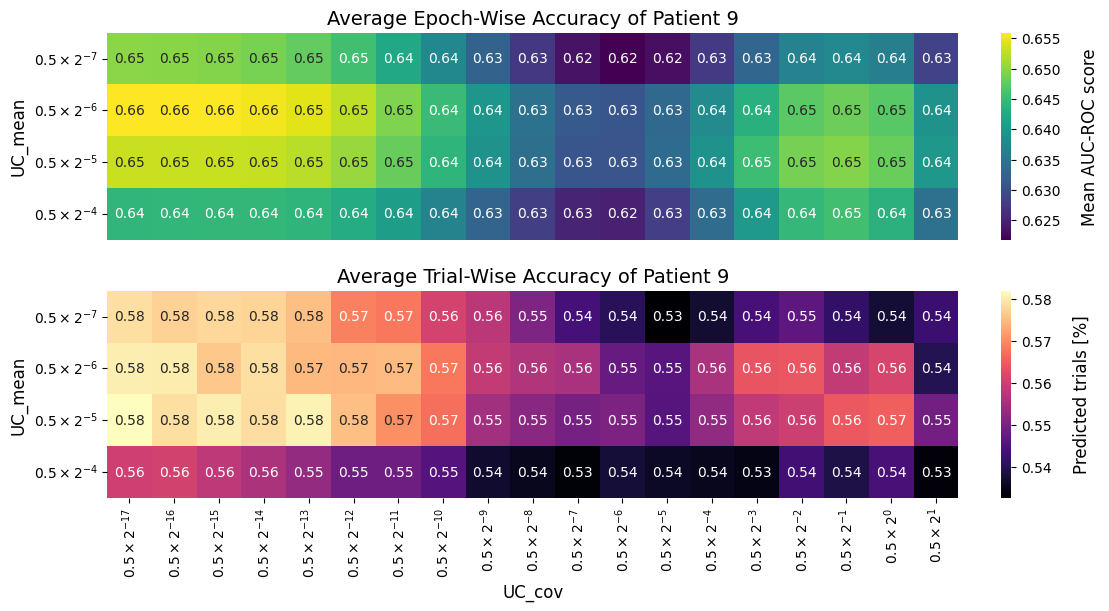

In [13]:
### Individual heatmap 

#To plot the heatmap of a single patient, fill in the patient number as p (this block here works only for the odd patients)
p = 9

patient_title = f"Patient {p}"
directory = "dataframes/" 
df = pd.read_csv(f"{directory}mean_UC_results_p{p}.csv")
pivot_tws = df.pivot(index="UC_mean", columns="UC_cov", values="TWS_mean")
pivot_ews = df.pivot(index="UC_mean", columns="UC_cov", values="EWS_mean")

plot_reduced_heatmaps(pivot_ews=pivot_ews, pivot_tws=pivot_tws, patient_title=patient_title, save_as=f"heatmap_p{p}")

### Individual learning curves with different optimal UC-pairs

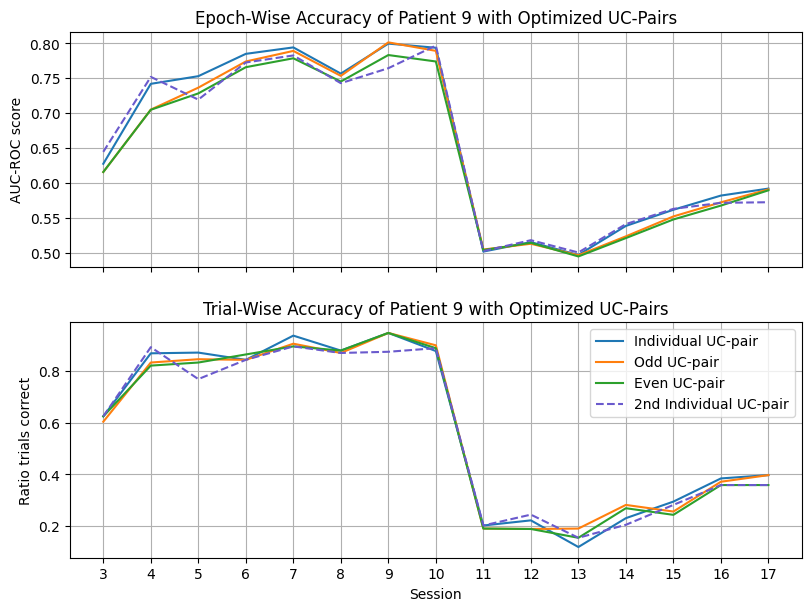

In [27]:
p =9
if p == 8:
    extra = 1
else:
    extra = 0    
for id in patients_db:
    if id==p:
        lon = patients_db.get(id).get('last_session')-1

directory = "dataframes/"
df = pd.read_csv(f"{directory}all_UC_results_p{p}.csv")

# Optimal UC-pair obtain from even patients
filtered_df = df[df["v"] == 6]
ews_even = np.array(filtered_df["EWS"])
tws_even = np.array(filtered_df["TWS"])

# Optimal UC-pair obtain from odd patients
filtered_df = df[df["v"] == 4]
ews_odd = np.array(filtered_df["EWS"])
tws_odd = np.array(filtered_df["TWS"])

# Individual optimal UC-pair (after looking at heatmaps)
filtered_df = df[df["v"] == 20]
ews_individual = np.array(filtered_df["EWS"])
tws_individual = np.array(filtered_df["TWS"])

# (Optional, if there are two optima in the heatmaps:) Second individual optimal UC-pair
filtered_df = df[df["v"] == 54]
ews_individual_v2 = np.array(filtered_df["EWS"])
tws_individual_v2 = np.array(filtered_df["TWS"])


# Create subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(nrows=2, 
                               figsize=(8, 6), 
                               sharex=True, 
                               constrained_layout=True
                               )

# Plot Epoch-Wise Score
#l1 = ax1.plot(ews_individual, label="Individual UC-pair", linewidth=3.0)
#l2 = ax1.plot(ews_odd, label="Odd UC-pair", linestyle="dashed")
l1 = ax1.plot(ews_individual, label="Individual UC-pair")
l2 = ax1.plot(ews_odd, label="Odd UC-pair")
l3 = ax1.plot(ews_even, label="Even UC-pair")
l4 = ax1.plot(ews_individual_v2, label=f"2nd Individual UC-pair", color="slateblue", linestyle="dashed")

ax1.set_title(f"Epoch-Wise Accuracy of Patient {p} with Optimized UC-Pairs", fontsize=12)
#ax1.legend()
ax1.set_xlabel(" ")
ax1.set_ylabel("AUC-ROC score", fontsize=10)
ax1.set_xticks(np.arange(0,lon-2-extra),np.arange(3+extra,lon+1))
#plt.ylim((0.25,1))
ax1.grid()

# Plot Trial-Wise Score
#ax2.plot(tws_individual, label=f"Individual UC-pair", linewidth=3.0)
#ax2.plot(tws_odd, label=f"Odd UC-pair", linestyle="dashed")
ax2.plot(tws_individual, label=f"Individual UC-pair")
ax2.plot(tws_odd, label=f"Odd UC-pair")
ax2.plot(tws_even, label=f"Even UC-pair")
ax2.plot(tws_individual_v2, label=f"2nd Individual UC-pair", color="slateblue", linestyle="dashed")

ax2.set_title(f"Trial-Wise Accuracy of Patient {p} with Optimized UC-Pairs", fontsize=12)
ax2.legend()
ax2.set_xlabel("Session", fontsize=10)
ax2.set_ylabel("Ratio trials correct", fontsize=10)
ax2.set_xticks(np.arange(0,lon-2-extra),np.arange(3+extra,lon+1))
#plt.ylim((0.25,1))
ax2.grid()

plt.savefig(f"learningcurve_uc_p{p}.svg", bbox_inches='tight')
plt.savefig(f"learningcurve_uc_p{p}.pdf", bbox_inches='tight')
plt.savefig(f"learningcurve_uc_p{p}.png", dpi=600, bbox_inches='tight')
plt.show()


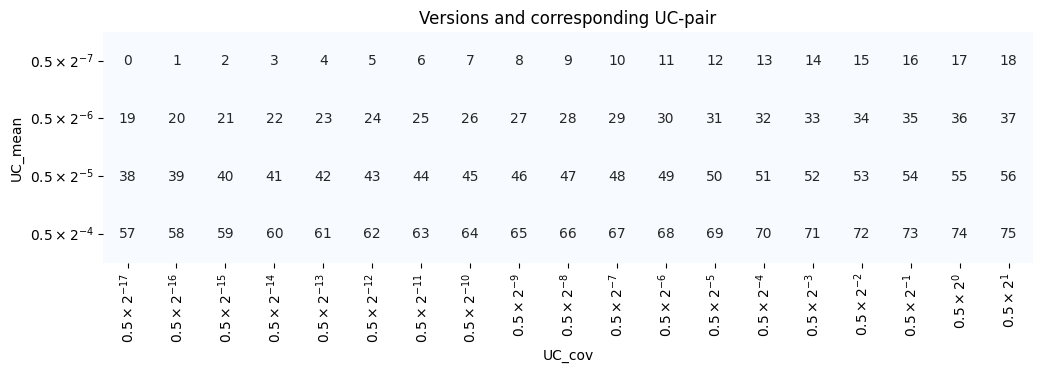

In [33]:
from uc_visualization import plot_versions_map

# Grid of versions their corresponding UC-pair. 
# This is not part of the thesis results, but rather relevant if you want to work with the results and understand their structure
plot_versions_map()